# Modèle Spécialisé - Prédiction d'Ethnicité

Ce notebook implémente un modèle de deep learning spécialisé dans la classification de l'ethnicité à partir de photos de visages.

**Architecture:** Transfer Learning avec EfficientNetB0
**Tâche:** Classification multi-classe (5 classes)
**Dataset:** UTKFace (23,708 images)

**Classes:**

- 0: White
- 1: Black
- 2: Asian
- 3: Indian
- 4: Others


## 1. Configuration et Imports


In [1]:
import os, sys, pathlib
import random
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0, MobileNetV3Large, MobileNetV3Small
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.losses import Huber
from tensorflow.keras.regularizers import l2
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


2026-03-27 22:01:14.018688: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 22:01:14.020290: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-27 22:01:14.048381: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-27 22:01:14.048416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-27 22:01:14.049478: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

TensorFlow version: 2.15.0
GPU disponible: []
Working dir set to /home/carld/face-analysis-deep-learning
{'BASE_DIR': '/home/carld/face-analysis-deep-learning', 'DATA_DIR': '/home/carld/face-analysis-deep-learning/data', 'RAW_DIR': '/home/carld/face-analysis-deep-learning/data/raw', 'IMAGES_DIR': '/home/carld/face-analysis-deep-learning/data/UTKFace', 'ARTIFACTS_DIR': '/home/carld/face-analysis-deep-learning/artifacts', 'ANDROID_ASSETS_DIR': '/home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets', 'TESTS_DIR': '/home/carld/face-analysis-deep-learning/tests', 'DIAGNOSTICS_DIR': '/home/carld/face-analysis-deep-learning/diagnostics', 'DATASET_ID': 'jangedoo/utkface-new'}


2026-03-27 22:01:15.647881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-27 22:01:15.648164: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Constantes et Hyperparamètres


In [2]:
# Chemins
DATA_DIR = IMAGES_DIR
DATASET_PATH = IMAGES_DIR
OUTPUT_DIR = artifacts_for("ethnicity", "ethnicity_prediction_model")
ARTIFACTS_DIR = OUTPUT_DIR

# Classes d'ethnicité
ETHNICITY_MAP = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}
NUM_CLASSES = len(ETHNICITY_MAP)
CLASS_NAMES = list(ETHNICITY_MAP.values())

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 15
FINETUNE_EPOCHS = 35
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

# Seed global pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)



print(f"Dataset: {DATASET_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Configuration:")
print(f"  - Classes: {CLASS_NAMES}")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")

Dataset: /home/carld/face-analysis-deep-learning/data/UTKFace
Output: /home/carld/face-analysis-deep-learning/artifacts/ethnicity/ethnicity_prediction_model
Configuration:
  - Classes: ['White', 'Black', 'Asian', 'Indian', 'Others']
  - Image size: 128x128
  - Batch size: 32


## 3. Chargement des Données


In [3]:
def parse_utkface_filename(filepath: Path) -> dict | None:
    """Parse les métadonnées depuis le nom de fichier UTKFace."""
    try:
        name = filepath.name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 3:
            return None

        ethnicity = int(parts[2]) if parts[2].isdigit() else -1

        # Filtrer les ethnicités invalides
        if ethnicity < 0 or ethnicity > 4:
            return None

        return {
            "filepath": str(filepath),
            "ethnicity": ethnicity,
            "ethnicity_name": ETHNICITY_MAP.get(ethnicity, "Unknown"),
        }
    except Exception:
        return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing des fichiers"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")

Images trouvées: 23708


Parsing des fichiers: 100%|██████████| 23708/23708 [00:00<00:00, 806215.01it/s]


Images valides: 23705


Distribution des ethnicités:
ethnicity_name
White     10078
Black      4526
Indian     3975
Asian      3434
Others     1692
Name: count, dtype: int64


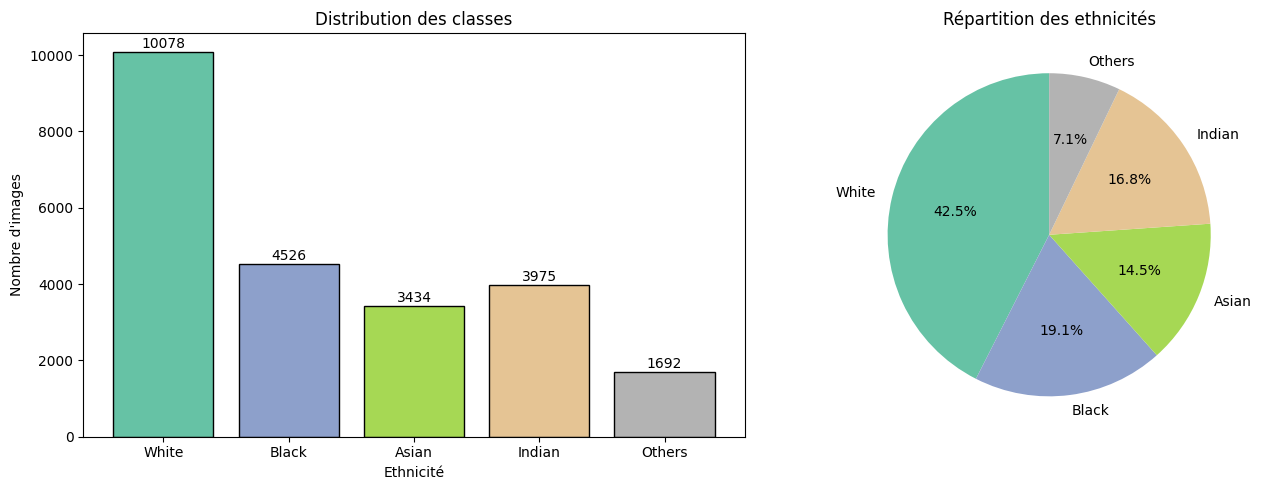


Ratio de déséquilibre max/min: 5.96


In [4]:
# Distribution des classes
print("Distribution des ethnicités:")
class_counts = df["ethnicity_name"].value_counts()
print(class_counts)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
class_counts_sorted = df["ethnicity"].value_counts().sort_index()
axes[0].bar(
    [ETHNICITY_MAP[i] for i in class_counts_sorted.index],
    class_counts_sorted.values,
    color=colors,
    edgecolor="black",
)
axes[0].set_xlabel("Ethnicité")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des classes")
for i, v in enumerate(class_counts_sorted.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    class_counts_sorted.values,
    labels=[ETHNICITY_MAP[i] for i in class_counts_sorted.index],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)
axes[1].set_title("Répartition des ethnicités")

plt.tight_layout()
plt.show()

# Calcul du déséquilibre
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nRatio de déséquilibre max/min: {imbalance_ratio:.2f}")

## 4. Split Train/Validation/Test (Stratifié)


In [5]:
# Split stratifié
X = df["filepath"].values
y = df["ethnicity"].values

# Premier split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

# Deuxième split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED,
)

print(f"Split des données:")
print(f"  - Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Vérifier la stratification
print(f"\nDistribution dans le train set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  - {ETHNICITY_MAP[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Split des données:
  - Train: 18963 (80.0%)
  - Validation: 2371 (10.0%)
  - Test: 2371 (10.0%)

Distribution dans le train set:
  - White: 8062 (42.5%)
  - Black: 3620 (19.1%)
  - Asian: 2748 (14.5%)
  - Indian: 3179 (16.8%)
  - Others: 1354 (7.1%)


## 5. Calcul des Poids de Classes


In [6]:
# Calculer les poids de classes pour gérer le déséquilibre
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print("Poids des classes:")
for cls, weight in class_weights.items():
    print(f"  - {ETHNICITY_MAP[cls]}: {weight:.3f}")

Poids des classes:
  - White: 0.470
  - Black: 1.048
  - Asian: 1.380
  - Indian: 1.193
  - Others: 2.801


## 7. Pipeline de Données avec Data Augmentation


In [7]:
# Couche de data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    """Charge et prétraite une image (sans normalisation pour permettre l'augmentation)."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def create_dataset(filepaths, labels, batch_size, shuffle=True, augment=False):
    """Crée un tf.data.Dataset."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Créer les datasets
train_ds = create_dataset(X_train, y_train, BATCH_SIZE, shuffle=True, augment=True)
val_ds = create_dataset(X_val, y_val, BATCH_SIZE, shuffle=False, augment=False)
test_ds = create_dataset(X_test, y_test, BATCH_SIZE, shuffle=False, augment=False)

print("Datasets créés avec succès!")

Datasets créés avec succès!


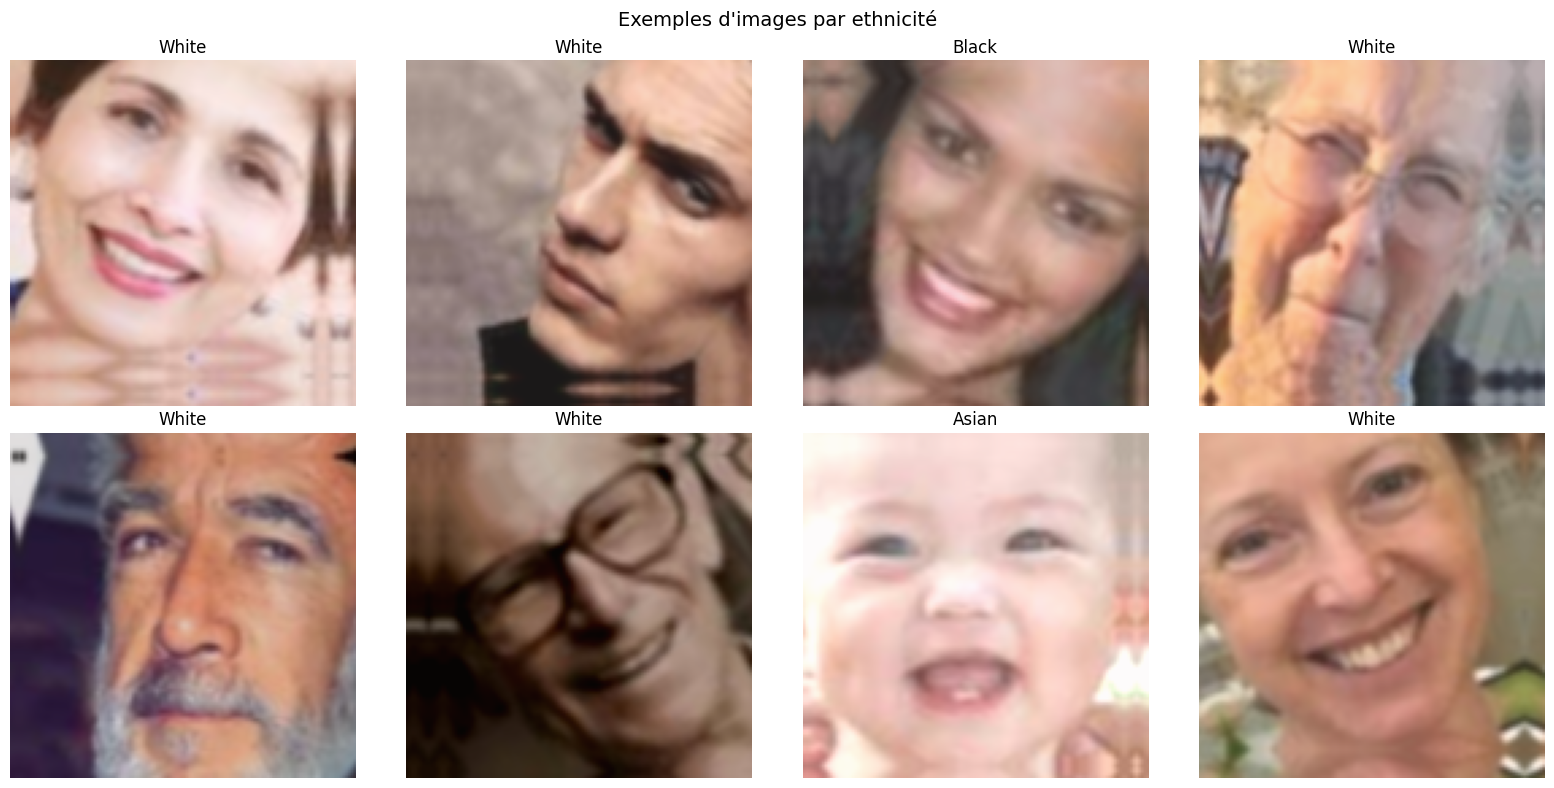

In [8]:
# Visualiser quelques exemples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            # Images sont en [0, 255], normaliser pour affichage
            img = images[i].numpy() / 255.0
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.set_title(f"{ETHNICITY_MAP[labels[i].numpy()]}")
            ax.axis("off")

plt.suptitle("Exemples d'images par ethnicité", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Construction du Modèle


In [9]:
def build_ethnicity_model(
    img_size: int, num_classes: int, trainable_backbone: bool = False
) -> Model:
    """Construit le modèle de classification d'ethnicité avec EfficientNetB0."""

    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # Backbone EfficientNetB0
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # Double pooling (GAP + GMP) pour capturer plus d'informations
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head de classification
    x = layers.Dense(256, activation="relu", name="dense_1")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.5, name="dropout_1")(x)

    x = layers.Dense(128, activation="relu", name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(0.4, name="dropout_2")(x)

    # Output (classification multi-classe)
    outputs = layers.Dense(num_classes, activation="softmax", name="ethnicity_output")(
        x
    )

    model = Model(inputs, outputs, name="EthnicityModel_EfficientNetB0")
    return model, backbone


# Construire le modèle
model, backbone = build_ethnicity_model(IMG_SIZE, NUM_CLASSES, trainable_backbone=False)
model.summary()

Model: "EthnicityModel_EfficientNetB0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_image (InputLayer)    [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 efficientnetb0 (Functional  (None, 4, 4, 1280)           4049571   ['input_image[0][0]']         
 )                                                                                                
                                                                                                  
 gap (GlobalAveragePooling2  (None, 1280)                 0         ['efficientnetb0[0][0]']      
 D)                                                                                               
                                                                      

## 9. Phase 1: Warmup (Backbone Gelé)


In [10]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR, decay_steps=total_warmup_steps, alpha=0.1
)

model.compile(
    optimizer=Adam(learning_rate=warmup_lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_warmup_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    # Note: Pas de ReduceLROnPlateau car CosineDecay gère déjà la décroissance du LR
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(
    f"Paramètres entraînables: {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}"
)

Phase 1: Warmup (15 epochs, backbone gelé)
Paramètres entraînables: 689,925


In [11]:
# Entraînement Phase 1
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/15
 19/593 [..............................] - ETA: 1:06 - loss: 2.2210 - accuracy: 0.2780

KeyboardInterrupt: 

## 10. Phase 2: Fine-tuning


In [ ]:
# Dégeler les dernières couches du backbone
backbone.trainable = True

freeze_until = len(backbone.layers) - 50
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (35 epochs)
Couches dégelées: 50/238
Paramètres entraînables: 3,216,789


In [ ]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR, decay_steps=total_finetune_steps, alpha=0.01
)

model.compile(
    optimizer=Adam(learning_rate=finetune_lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "ethnicity_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    # Note: Pas de ReduceLROnPlateau car CosineDecay gère déjà la décroissance du LR
]

In [ ]:
# Entraînement Phase 2
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/35
591/593 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4304 - loss: 1.4770

2026-01-18 12:28:19.770066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:28:19.857494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:28:19.944320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:28:20.032023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4305 - loss: 1.4768
Epoch 1: val_accuracy improved from None to 0.55715, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_model_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_model_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - accuracy: 0.4534 - loss: 1.4164 - val_accuracy: 0.5571 - val_loss: 1.1453
Epoch 2/35
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5013 - loss: 1.3138
Epoch 2: val_accuracy improved from 0.55715 to 0.60101, saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_model_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/ethnicity_model_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5154 - loss: 1.2772 - val_accuracy: 0.6010 - val_loss: 1.0445
Epoch 3/35
591/593 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5360 - loss: 1.2300
Epoch 3: val_accuracy improved from 0.601

## 11. Visualisation de l'Entraînement


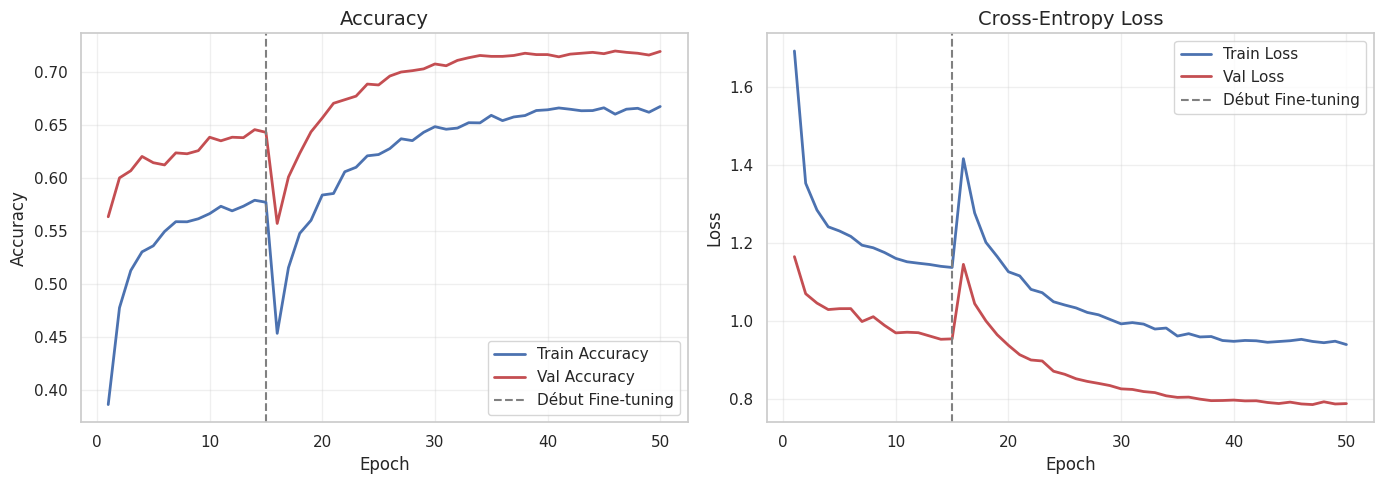


Meilleure Val Accuracy: 0.7199 (epoch 46)


In [ ]:
def plot_training_history(warmup_hist, finetune_hist):
    """Visualise l'historique d'entraînement."""
    combined_acc = warmup_hist.history["accuracy"] + finetune_hist.history["accuracy"]
    combined_val_acc = (
        warmup_hist.history["val_accuracy"] + finetune_hist.history["val_accuracy"]
    )
    combined_loss = warmup_hist.history["loss"] + finetune_hist.history["loss"]
    combined_val_loss = (
        warmup_hist.history["val_loss"] + finetune_hist.history["val_loss"]
    )

    epochs = range(1, len(combined_acc) + 1)
    warmup_end = len(warmup_hist.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs, combined_acc, "b-", label="Train Accuracy", linewidth=2)
    axes[0].plot(epochs, combined_val_acc, "r-", label="Val Accuracy", linewidth=2)
    axes[0].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, combined_loss, "b-", label="Train Loss", linewidth=2)
    axes[1].plot(epochs, combined_val_loss, "r-", label="Val Loss", linewidth=2)
    axes[1].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Cross-Entropy Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "ethnicity_training_history.png", dpi=150)
    plt.show()

    best_val_acc = max(combined_val_acc)
    best_epoch = combined_val_acc.index(best_val_acc) + 1
    print(f"\nMeilleure Val Accuracy: {best_val_acc:.4f} (epoch {best_epoch})")


plot_training_history(warmup_history, finetune_history)

## 12. Évaluation sur le Test Set


In [ ]:
# Charger le meilleur modèle
best_model = keras.models.load_model(ARTIFACTS_DIR / "ethnicity_model_best.keras")

# Évaluation
test_results = best_model.evaluate(test_ds, verbose=1)
print(f"\nRésultats sur le test set:")
print(f"  - Loss: {test_results[0]:.4f}")
print(f"  - Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.7212 - loss: 0.7851

Résultats sur le test set:
  - Loss: 0.7851
  - Accuracy: 0.7212 (72.12%)


In [ ]:
# Prédictions détaillées
y_pred_proba = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

# Métriques
accuracy = np.mean(y_pred == y_true)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print(f"\nMétriques détaillées:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - F1 Score (macro): {f1_macro:.4f}")
print(f"  - F1 Score (weighted): {f1_weighted:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step

Métriques détaillées:
  - Accuracy: 0.7212
  - F1 Score (macro): 0.6454
  - F1 Score (weighted): 0.7268


In [ ]:
# Rapport de classification détaillé
print("\nRapport de classification:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Rapport de classification:
              precision    recall  f1-score   support

       White       0.85      0.79      0.82      1008
       Black       0.79      0.81      0.80       453
       Asian       0.63      0.82      0.72       343
      Indian       0.74      0.51      0.60       398
      Others       0.24      0.36      0.29       169

    accuracy                           0.72      2371
   macro avg       0.65      0.66      0.65      2371
weighted avg       0.75      0.72      0.73      2371



## 13. Matrice de Confusion


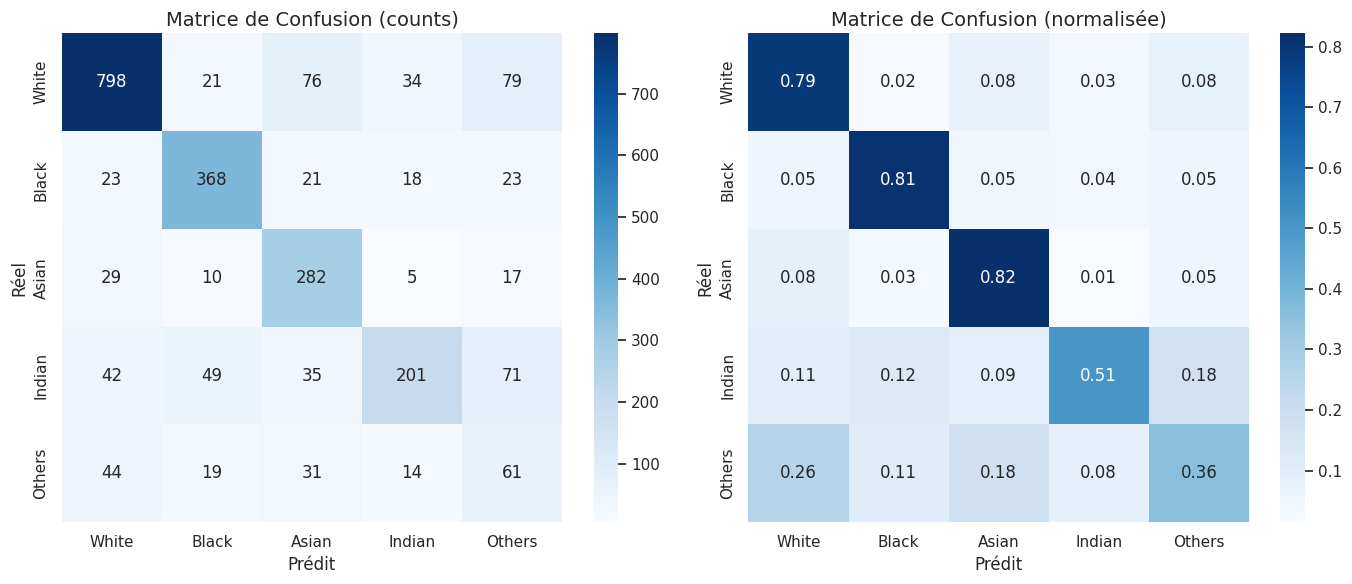

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de Confusion (counts)")

# Normalized
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Matrice de Confusion (normalisée)")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "ethnicity_confusion_matrix.png", dpi=150)
plt.show()

## 14. Analyse des Erreurs par Classe


In [ ]:
# Analyse par classe
results_df = pd.DataFrame(
    {
        "true": y_true,
        "predicted": y_pred,
        "true_name": [ETHNICITY_MAP[y] for y in y_true],
        "predicted_name": [ETHNICITY_MAP[y] for y in y_pred],
        "correct": y_pred == y_true,
        "confidence": y_pred_proba.max(axis=1),
    }
)

# Accuracy et confiance par classe
class_analysis = (
    results_df.groupby("true_name")
    .agg({"correct": ["mean", "sum", "count"], "confidence": "mean"})
    .round(3)
)
class_analysis.columns = ["Accuracy", "Correct", "Total", "Avg Confidence"]
print("Analyse par classe:")
display(class_analysis)

Analyse par classe:


,Accuracy,Correct,Total,Avg Confidence
true_name,,,,
Asian,0.822,282,343,0.731
Black,0.812,368,453,0.736
Indian,0.505,201,398,0.571
Others,0.361,61,169,0.543
White,0.792,798,1008,0.700


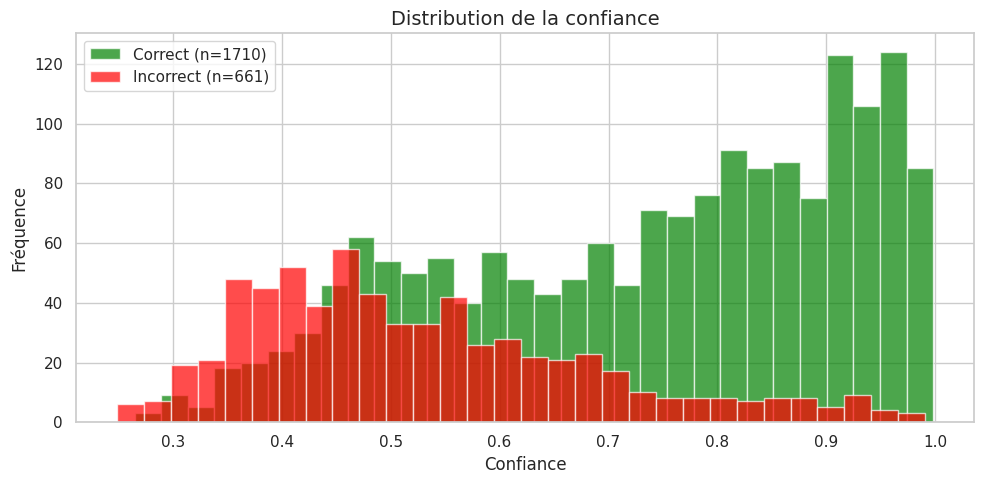

Confiance moyenne (correct): 0.738
Confiance moyenne (incorrect): 0.526


In [ ]:
# Distribution de la confiance pour les prédictions correctes vs incorrectes
fig, ax = plt.subplots(figsize=(10, 5))

correct_conf = results_df[results_df["correct"]]["confidence"]
incorrect_conf = results_df[~results_df["correct"]]["confidence"]

ax.hist(
    correct_conf,
    bins=30,
    alpha=0.7,
    label=f"Correct (n={len(correct_conf)})",
    color="green",
)
ax.hist(
    incorrect_conf,
    bins=30,
    alpha=0.7,
    label=f"Incorrect (n={len(incorrect_conf)})",
    color="red",
)
ax.set_xlabel("Confiance")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution de la confiance")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Confiance moyenne (correct): {correct_conf.mean():.3f}")
print(f"Confiance moyenne (incorrect): {incorrect_conf.mean():.3f}")

## 15. Exemples de Prédictions


2026-01-18 12:36:09.024765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:36:09.111224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:36:09.198525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:36:09.285453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:36:09.372203: E external/local_xla/xla/stream_

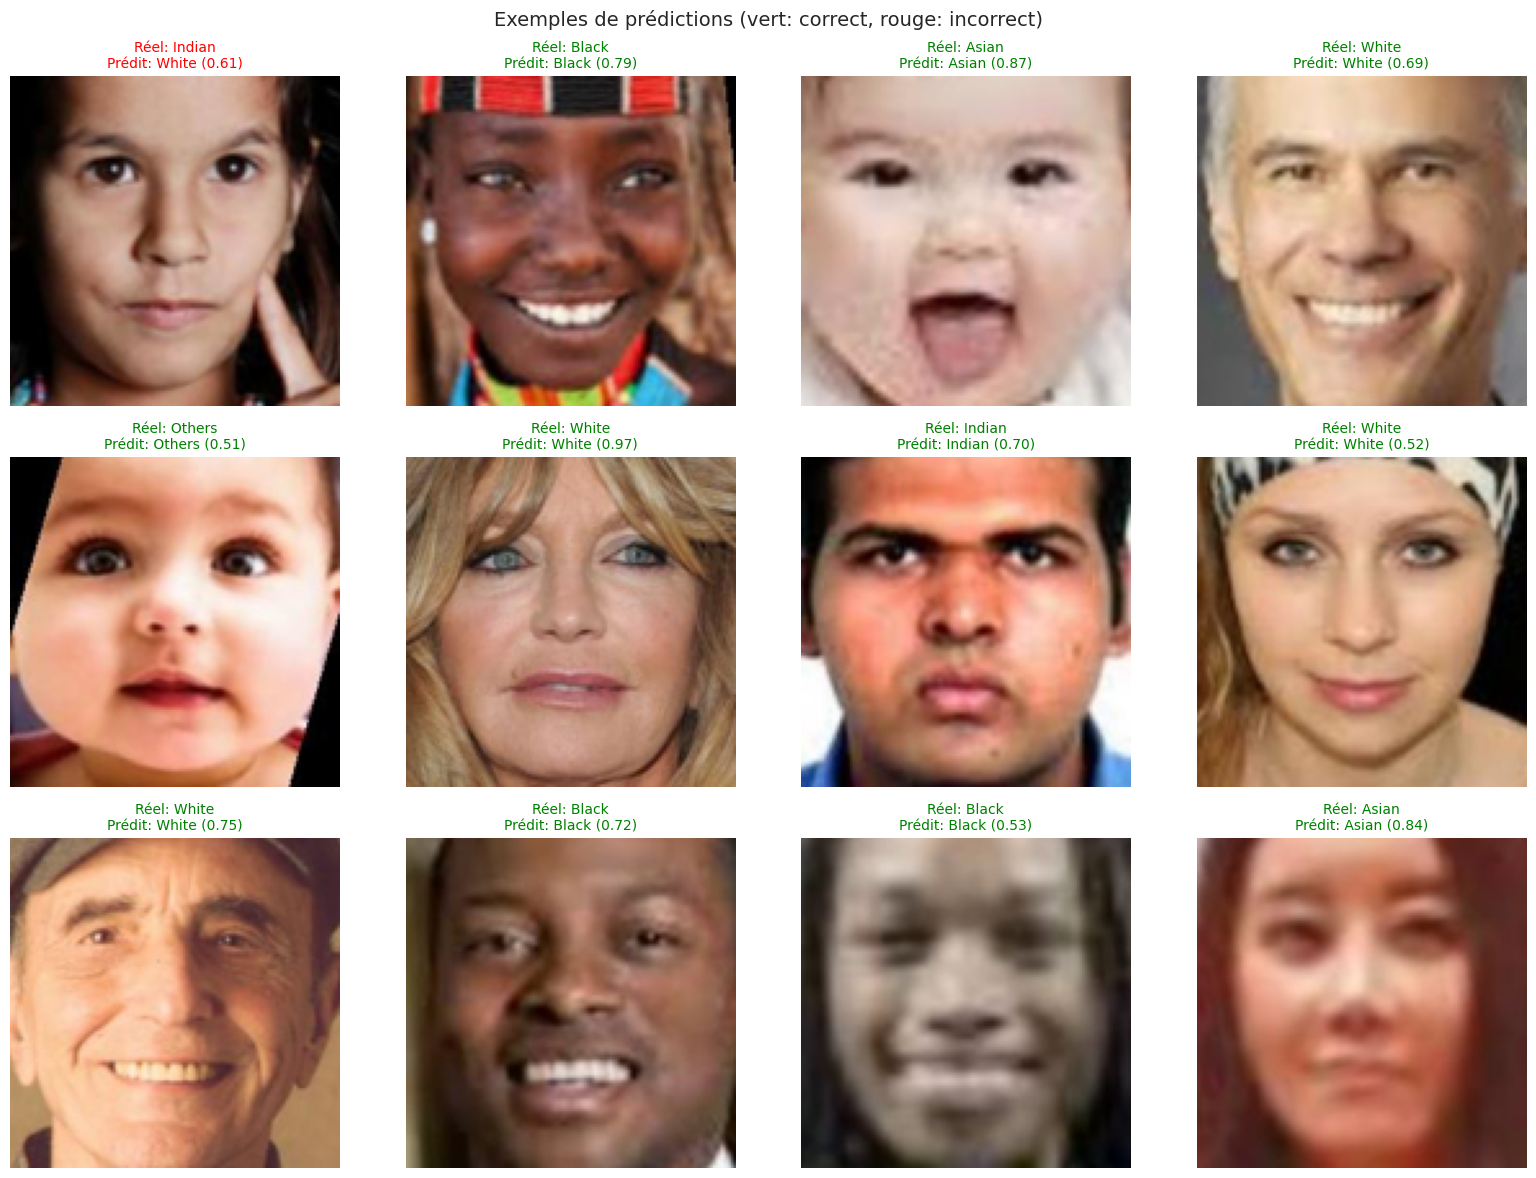

In [ ]:
def show_predictions(model, filepaths, true_labels, n_samples=12):
    """Affiche une grille de prédictions."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)  # En [0, 255]

        proba = model.predict(img_array[np.newaxis, ...], verbose=0)[0]
        pred = np.argmax(proba)
        conf = proba[pred]
        true = true_labels[idx]

        # Afficher l'image originale (normalisée en [0, 1])
        ax.imshow(img_array / 255.0)
        color = "green" if pred == true else "red"
        ax.set_title(
            f"Réel: {ETHNICITY_MAP[true]}\nPrédit: {ETHNICITY_MAP[pred]} ({conf:.2f})",
            color=color,
            fontsize=10,
        )
        ax.axis("off")

    plt.suptitle(
        "Exemples de prédictions (vert: correct, rouge: incorrect)", fontsize=14
    )
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "ethnicity_predictions_examples.png", dpi=150)
    plt.show()


show_predictions(best_model, X_test, y_test)

## 16. Sauvegarde du Modèle Final


In [ ]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "ethnicity_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les infos du modèle et les classes
import json

model_info = {
    "img_size": IMG_SIZE,
    "classes": CLASS_NAMES,
    "class_map": {str(k): v for k, v in ETHNICITY_MAP.items()},
    "input_range": [0, 255],  # Plage des valeurs d'entrée attendues
}

with open(ARTIFACTS_DIR / "ethnicity_model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/ethnicity_model_final.keras
Infos du modèle sauvegardées


In [ ]:
# Conversion en TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "ethnicity_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpd9fi0_h9/assets


INFO:tensorflow:Assets written to: /tmp/tmpd9fi0_h9/assets


Saved artifact at '/tmp/tmpd9fi0_h9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  128859249214288: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128859249213904: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  128857354643664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354645968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354639440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354646736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354647312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354647504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354644816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128857354646928: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1768736180.398630   31949 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768736180.398648   31949 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768736180.500988   31949 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 17. Résumé des Performances


In [ ]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE DE CLASSIFICATION D'ETHNICITÉ")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Classes: {CLASS_NAMES}")
print(
    f"Dataset: {len(df)} images (train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)})"
)
print(f"\nPerformances sur le test set:")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - F1 Score (macro): {f1_macro:.4f}")
print(f"  - F1 Score (weighted): {f1_weighted:.4f}")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE DE CLASSIFICATION D'ETHNICITÉ

Architecture: EfficientNetB0 + Dense Head
Input size: 128x128x3
Classes: ['White', 'Black', 'Asian', 'Indian', 'Others']
Dataset: 23705 images (train: 18963, val: 2371, test: 2371)

Performances sur le test set:
  - Accuracy: 0.7212 (72.12%)
  - F1 Score (macro): 0.6454
  - F1 Score (weighted): 0.7268

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_model_final.keras
  - /home/optimalako/Projet/SAE/artifacts/ethnicity_model.tflite
